<a href="https://colab.research.google.com/github/vappanna/BerAIML/blob/main/MachineDemandForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: Upload your Merged Machine Sales CSV:


Saving Historical__and_future.csv to Historical__and_future.csv


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1386: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1386: RuntimeWarning: invalid value encountered in scalar add
  aicc = aic + aicc_penalty
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarni


⚠️ Alert: 127 models flagged with high volatility (MAPE > 25%).


<IPython.core.display.Javascript object>

...


✅ Success! Downloading Metrics and Projections...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

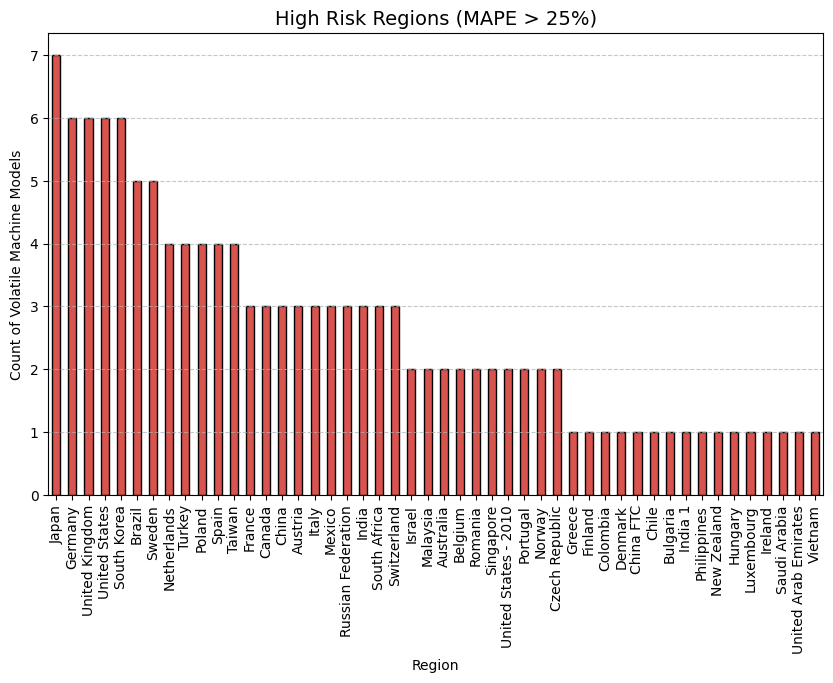

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import files
import io

def run_final_machine_forecast_with_mape():
    # --- 1. UPLOAD ---
    print("STEP 1: Upload your Merged Machine Sales CSV:")
    uploaded = files.upload()
    if not uploaded: return
    df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))
    df = df.sort_values(['Region', 'Machine', 'Quarter'])

    future_quarters = ['2026Q3', '2026Q4', '2027Q1', '2027Q2', '2027Q3', '2027Q4']
    forecast_list, metrics_list = [], []

    # --- 2. THE TOURNAMENT ---
    for (region, machine), group in df.groupby(['Region', 'Machine']):
        series = group['Install_Count'].values
        if len(series) < 4: continue

        try:
            # Backtest (Validation on last 2 quarters)
            train, test = series[:-2], series[-2:]
            avg_test = np.mean(test) if np.mean(test) > 0 else 1

            # Model A: Holt-Winters
            hw_preds = ExponentialSmoothing(train, trend='add').fit().forecast(2)
            hw_rmse = np.sqrt(mean_squared_error(test, hw_preds))

            # Model B: Moving Average
            ma_preds = [np.mean(train[-4:])] * 2
            ma_rmse = np.sqrt(mean_squared_error(test, ma_preds))

            # Winner Selection
            if hw_rmse <= ma_rmse:
                winner, win_rmse = "Holt-Winters", hw_rmse
                final_preds = ExponentialSmoothing(series, trend='add').fit().forecast(6)
            else:
                winner, win_rmse = "Moving Average", ma_rmse
                final_preds = [np.mean(series[-4:])] * 6

            # Calculate MAPE explicitly
            win_mae = mean_absolute_error(test, (hw_preds if winner == "Holt-Winters" else ma_preds))
            mape_val = (win_mae / avg_test) * 100

            metrics_list.append({
                'Region': region, 'Machine': machine, 'Model_Used': winner,
                'RMSE': round(win_rmse, 2), 'MAE': round(win_mae, 2),
                'MAPE': round(mape_val, 2), 'MAPE_Pct_String': f"{round(mape_val, 2)}%"
            })

            for q, p in zip(future_quarters, final_preds):
                forecast_list.append({'Region': region, 'Machine': machine, 'Quarter': q, 'Projected_Install_Count': max(0, round(p, 0))})
        except: continue

    # --- 3. EXPORT DATA ---
    df_metrics = pd.DataFrame(metrics_list)
    df_forecast = pd.DataFrame(forecast_list)
    df_metrics.to_csv("Machine_Model_Metrics_Final.csv", index=False)
    df_forecast.to_csv("Machine_Sales_Projection_2027.csv", index=False)

    # --- 4. VISUALIZE MAPE RISK (> 25%) ---
    high_mape = df_metrics[df_metrics['MAPE'] > 25]
    if not high_mape.empty:
        plt.figure(figsize=(10, 6))
        risk_counts = high_mape['Region'].value_counts()
        risk_counts.plot(kind='bar', color='#d9534f', edgecolor='black')
        plt.title('High Risk Regions (MAPE > 25%)', fontsize=14)
        plt.ylabel('Count of Volatile Machine Models')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.savefig("MAPE_Risk_Chart.png")
        print(f"\n⚠️ Alert: {len(high_mape)} models flagged with high volatility (MAPE > 25%).")
        files.download("MAPE_Risk_Chart.png")

    print("\n✅ Success! Downloading Metrics and Projections...")
    files.download("Machine_Model_Metrics_Final.csv")
    files.download("Machine_Sales_Projection_2027.csv")

# EXECUTE
run_final_machine_forecast_with_mape()